# Week 11 — Data Visualization

**IT 2012 — Unstructured Data**


## Learning Objectives

By the end of this notebook you will be able to:

1. Create **line, bar, scatter, histogram, and box plots** with matplotlib
2. Customize plots with titles, labels, legends, annotations, and subplots
3. Build **statistical visualizations** with seaborn (distributions, categories, heatmaps)
4. Create **interactive charts** with Plotly Express (hover, zoom, export)
5. Generate charts **programmatically** in a loop for automated reports
6. **Save figures** in PNG, PDF, SVG, and HTML formats

---
## 1. Setup and Sample Data

We'll use a synthetic dataset that represents metrics from a document extraction pipeline — the kind of data you'd have after running the tools from earlier weeks (PDF extraction, OCR, audio transcription, web scraping).

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for notebook display
%matplotlib inline

# Set a clean default style
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

print("✓ All imports successful")
print(f"  NumPy {np.__version__}")
print(f"  pandas {pd.__version__}")
print(f"  matplotlib {plt.matplotlib.__version__}")

✓ All imports successful
  NumPy 2.4.4
  pandas 3.0.2
  matplotlib 3.10.8


In [2]:
# Generate synthetic pipeline data
np.random.seed(42)

n = 200
sources = np.random.choice(['PDF', 'Image/OCR', 'Audio', 'Web'], size=n, p=[0.3, 0.25, 0.2, 0.25])
months = np.random.choice(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'], size=n)
languages = np.random.choice(['English', 'Bosnian', 'German', 'Turkish'], size=n, p=[0.4, 0.3, 0.15, 0.15])

# Processing time depends on source type
processing_time = np.where(sources == 'PDF', np.random.normal(3.5, 1.2, n),
                  np.where(sources == 'Image/OCR', np.random.normal(8.0, 3.0, n),
                  np.where(sources == 'Audio', np.random.normal(15.0, 5.0, n),
                           np.random.normal(2.0, 0.8, n))))
processing_time = np.clip(processing_time, 0.5, 40)

# Word count depends on source type
word_count = np.where(sources == 'PDF', np.random.normal(2500, 800, n),
             np.where(sources == 'Image/OCR', np.random.normal(150, 80, n),
             np.where(sources == 'Audio', np.random.normal(1200, 400, n),
                      np.random.normal(800, 300, n))))
word_count = np.clip(word_count, 10, 6000).astype(int)

# Quality score
quality = np.where(sources == 'PDF', np.random.normal(0.92, 0.05, n),
          np.where(sources == 'Image/OCR', np.random.normal(0.72, 0.12, n),
          np.where(sources == 'Audio', np.random.normal(0.85, 0.08, n),
                   np.random.normal(0.88, 0.06, n))))
quality = np.clip(quality, 0.3, 1.0)

# File size in KB
file_size = np.where(sources == 'PDF', np.random.exponential(500, n),
            np.where(sources == 'Image/OCR', np.random.exponential(1200, n),
            np.where(sources == 'Audio', np.random.exponential(3000, n),
                     np.random.exponential(80, n))))

df = pd.DataFrame({
    'source_type': sources,
    'month': pd.Categorical(months, categories=['Jan','Feb','Mar','Apr','May','Jun'], ordered=True),
    'language': languages,
    'processing_time_sec': np.round(processing_time, 2),
    'word_count': word_count,
    'quality_score': np.round(quality, 3),
    'file_size_kb': np.round(file_size, 1)
})

print(f"Dataset: {len(df)} documents")
print(f"Columns: {list(df.columns)}")
df.head(10)

Dataset: 200 documents
Columns: ['source_type', 'month', 'language', 'processing_time_sec', 'word_count', 'quality_score', 'file_size_kb']


,source_type,month,language,processing_time_sec,word_count,quality_score,file_size_kb
0,Image/OCR,Apr,Turkish,8.08,101,0.857,1051.3
1,Web,Mar,English,3.25,773,0.919,6.8
2,Audio,Jan,English,10.72,1079,0.839,18.8
3,Audio,Apr,German,28.71,1289,0.769,191.7
4,PDF,Jun,German,2.45,2848,0.846,413.4
5,PDF,Apr,English,2.69,3213,0.933,724.4
6,PDF,Jun,Bosnian,3.90,2969,0.994,1410.2
7,Web,Mar,Bosnian,1.84,1050,0.845,177.5
8,Audio,Jun,English,21.67,1536,0.810,2159.6
9,Audio,Jan,Turkish,16.59,1054,0.839,648.7


In [3]:
# Quick summary
df.describe().round(2)

,processing_time_sec,word_count,quality_score,file_size_kb
count,200.00,200.00,200.00,200.00
mean,6.63,1241.28,0.85,952.76
std,6.09,1059.57,0.11,1575.14
min,0.50,10.00,0.55,0.00
25%,2.57,277.75,0.81,71.20
50%,4.02,987.00,0.88,394.50
75%,8.77,1891.25,0.93,1121.92
max,28.71,4659.00,1.00,13485.10


---
## 2. matplotlib Basics — The Foundation

matplotlib is the **foundational** plotting library in Python. Every other visualization library (seaborn, pandas plotting, Plotly) builds on or interoperates with it.

**Key concept:** The *object-oriented* interface (`fig, ax = plt.subplots()`) gives you explicit control over every element. We'll use this approach throughout.

### 2.1 Line Plot — Trends Over Time

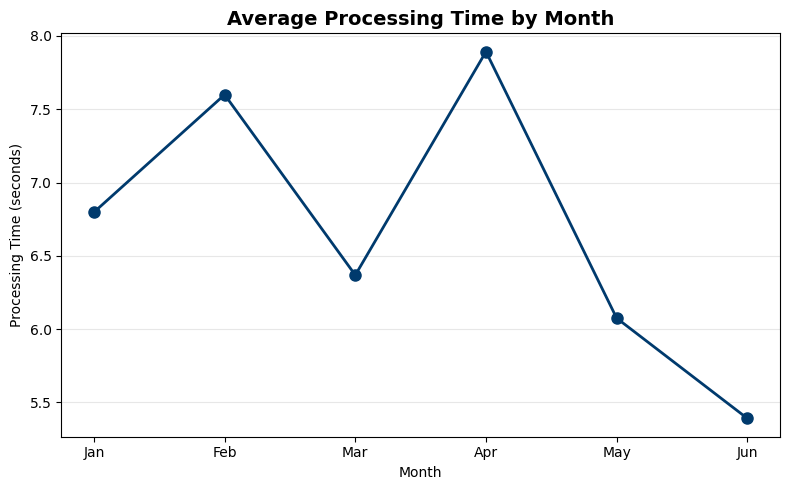

In [4]:
# Aggregate: average processing time per month
monthly_avg = df.groupby('month')['processing_time_sec'].mean()

fig, ax = plt.subplots()
ax.plot(monthly_avg.index, monthly_avg.values, 
        color='#003a6d', marker='o', linewidth=2, markersize=8)

ax.set_title('Average Processing Time by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Processing Time (seconds)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Bar Chart — Comparing Categories

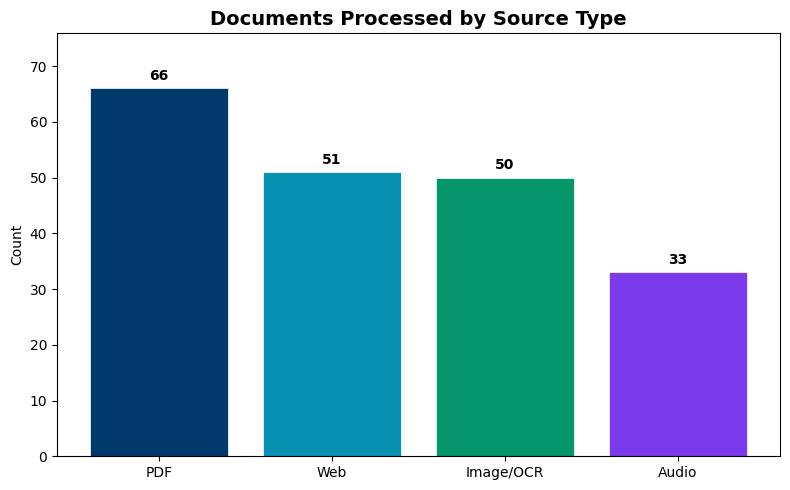

In [5]:
# Document count by source type
source_counts = df['source_type'].value_counts()

fig, ax = plt.subplots()
bars = ax.bar(source_counts.index, source_counts.values, 
              color=['#003a6d', '#0891B2', '#059669', '#7C3AED'],
              edgecolor='white', linewidth=0.5)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Documents Processed by Source Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, source_counts.max() * 1.15)

plt.tight_layout()
plt.show()

### 2.3 Scatter Plot — Relationships Between Variables

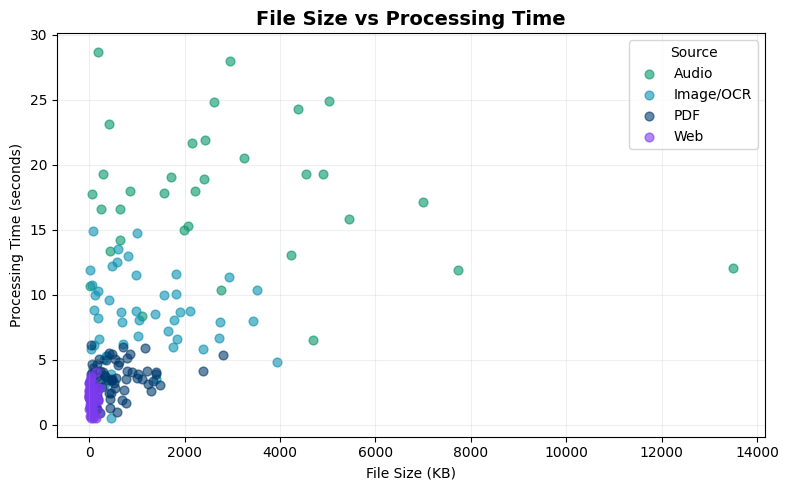

In [6]:
# Scatter: file size vs processing time, colored by source
colors = {'PDF': '#003a6d', 'Image/OCR': '#0891B2', 'Audio': '#059669', 'Web': '#7C3AED'}

fig, ax = plt.subplots()
for source, group in df.groupby('source_type'):
    ax.scatter(group['file_size_kb'], group['processing_time_sec'],
               label=source, color=colors[source], alpha=0.6, s=40)

ax.set_title('File Size vs Processing Time', fontsize=14, fontweight='bold')
ax.set_xlabel('File Size (KB)')
ax.set_ylabel('Processing Time (seconds)')
ax.legend(title='Source')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 2.4 Histogram — Distribution of Values

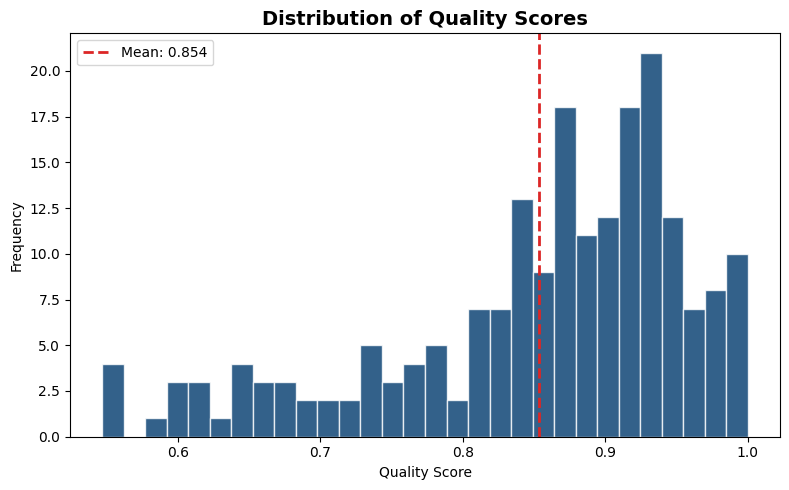

In [7]:
fig, ax = plt.subplots()

ax.hist(df['quality_score'], bins=30, color='#003a6d', edgecolor='white', alpha=0.8)

ax.set_title('Distribution of Quality Scores', fontsize=14, fontweight='bold')
ax.set_xlabel('Quality Score')
ax.set_ylabel('Frequency')
ax.axvline(df['quality_score'].mean(), color='#DC2626', linestyle='--', 
           linewidth=2, label=f"Mean: {df['quality_score'].mean():.3f}")
ax.legend()

plt.tight_layout()
plt.show()

### 2.5 Box Plot — Spread and Outliers

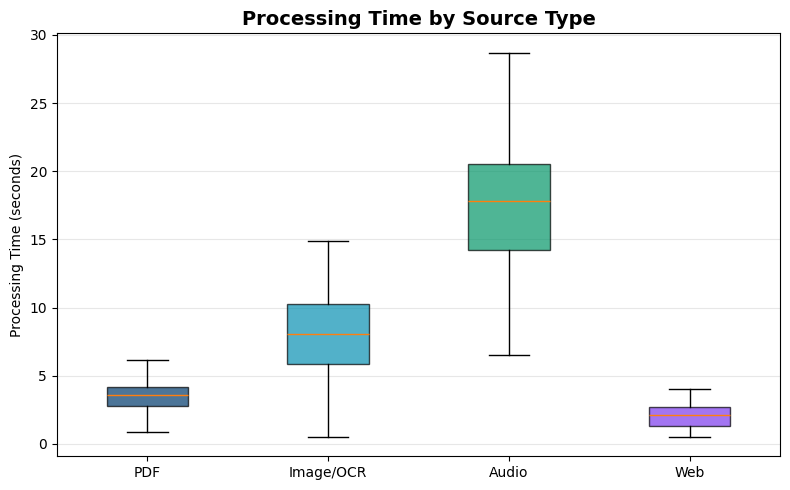

In [8]:
fig, ax = plt.subplots()

# Prepare data for box plot
data_by_source = [df[df['source_type'] == s]['processing_time_sec'] 
                  for s in ['PDF', 'Image/OCR', 'Audio', 'Web']]

bp = ax.boxplot(data_by_source, labels=['PDF', 'Image/OCR', 'Audio', 'Web'],
                patch_artist=True)

# Color the boxes
box_colors = ['#003a6d', '#0891B2', '#059669', '#7C3AED']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Processing Time by Source Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Processing Time (seconds)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Customization and Subplots

Real-world visualizations need **titles, annotations, multiple panels,** and **export to files**.

### 3.1 Annotations — Highlighting Key Points

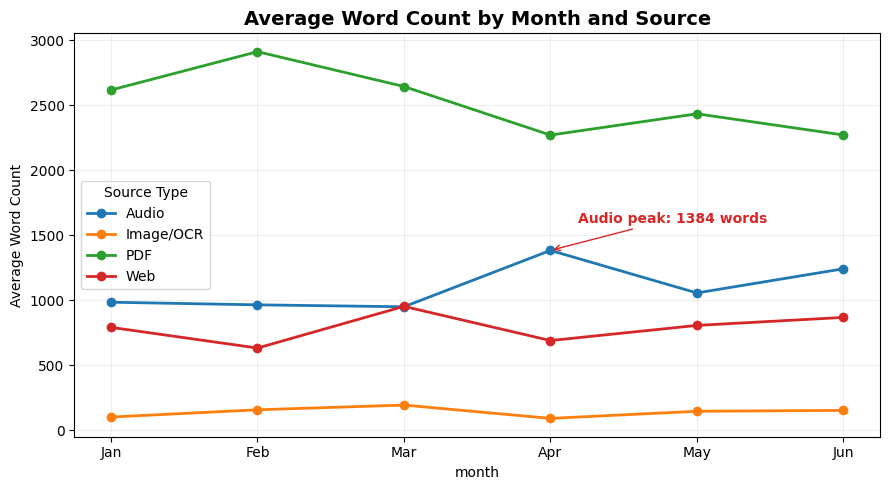

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

# Monthly word count by source
monthly_source = df.groupby(['month', 'source_type'])['word_count'].mean().unstack()
monthly_source.plot(ax=ax, linewidth=2, marker='o')

# Annotate the peak
peak_month = monthly_source['Audio'].idxmax()
peak_value = monthly_source['Audio'].max()
ax.annotate(f'Audio peak: {peak_value:.0f} words',
            xy=(monthly_source.index.get_loc(peak_month), peak_value),
            xytext=(20, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='#DC2626'),
            fontsize=10, color='#DC2626', fontweight='bold')

ax.set_title('Average Word Count by Month and Source', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Word Count')
ax.legend(title='Source Type')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 3.2 Subplots — Multiple Charts in One Figure

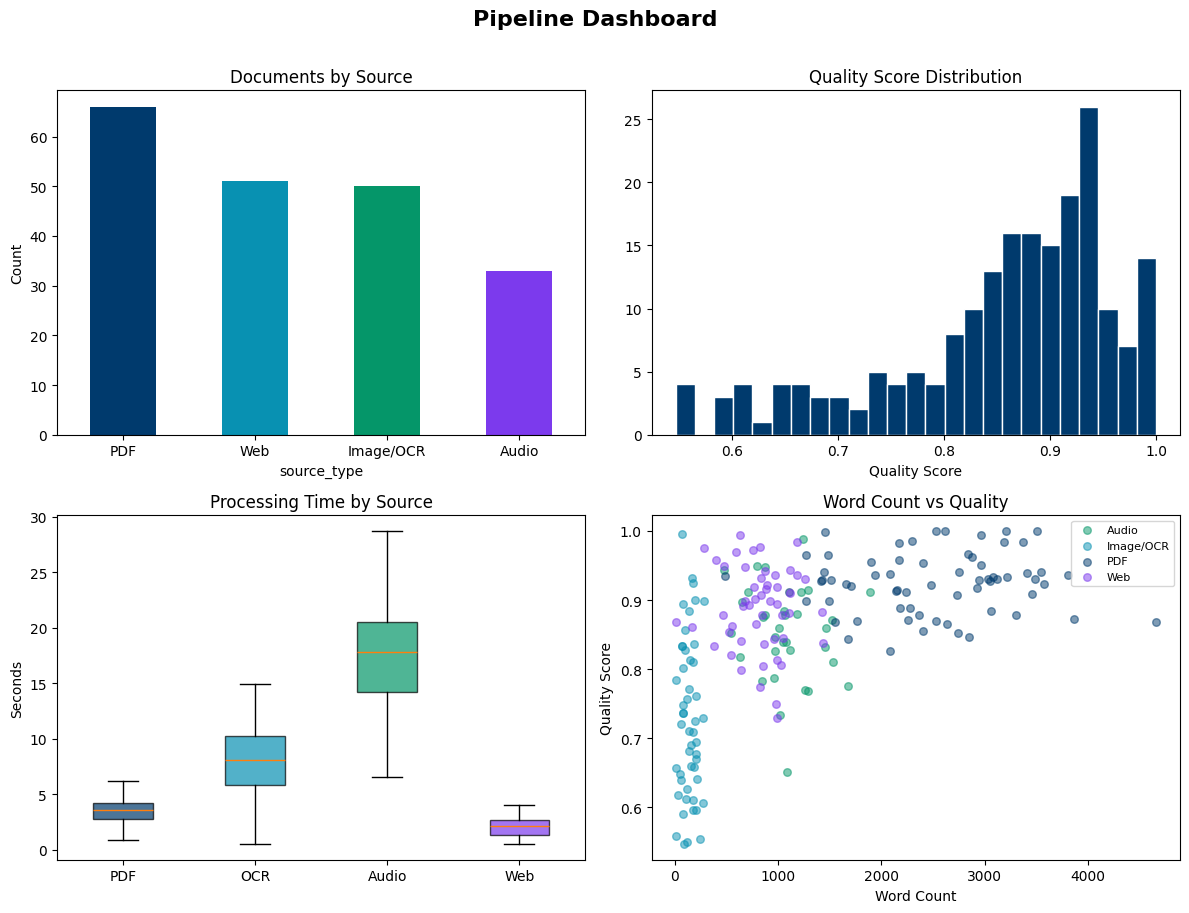

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Pipeline Dashboard', fontsize=16, fontweight='bold', y=1.01)

# Top-left: Bar chart
source_counts.plot.bar(ax=axes[0, 0], color=['#003a6d', '#0891B2', '#059669', '#7C3AED'])
axes[0, 0].set_title('Documents by Source')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0)

# Top-right: Histogram
axes[0, 1].hist(df['quality_score'], bins=25, color='#003a6d', edgecolor='white')
axes[0, 1].set_title('Quality Score Distribution')
axes[0, 1].set_xlabel('Quality Score')

# Bottom-left: Box plot
bp = axes[1, 0].boxplot(data_by_source, labels=['PDF', 'OCR', 'Audio', 'Web'], patch_artist=True)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_title('Processing Time by Source')
axes[1, 0].set_ylabel('Seconds')

# Bottom-right: Scatter
for source, group in df.groupby('source_type'):
    axes[1, 1].scatter(group['word_count'], group['quality_score'],
                       label=source, alpha=0.5, s=30, color=colors[source])
axes[1, 1].set_title('Word Count vs Quality')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Quality Score')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 3.3 Saving Figures

✓ Saved: chart_example.png (300 DPI raster)
✓ Saved: chart_example.pdf (vector format)


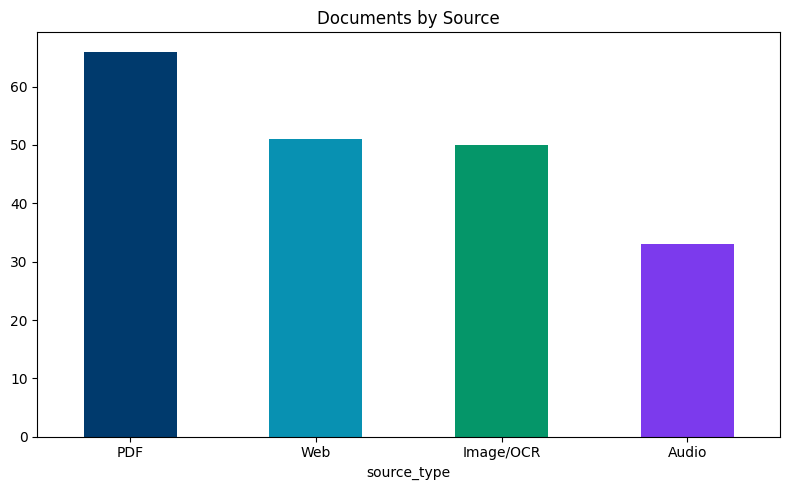

In [11]:
# Create a simple chart and save it
fig, ax = plt.subplots()
source_counts.plot.bar(ax=ax, color=['#003a6d', '#0891B2', '#059669', '#7C3AED'])
ax.set_title('Documents by Source')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()

# Save to different formats
fig.savefig('chart_example.png', dpi=300, bbox_inches='tight')
fig.savefig('chart_example.pdf', bbox_inches='tight')
print("✓ Saved: chart_example.png (300 DPI raster)")
print("✓ Saved: chart_example.pdf (vector format)")
plt.show()

---
## 4. seaborn — Statistical Visualization

seaborn builds on matplotlib with **higher-level functions**, **automatic aggregation**, and **beautiful defaults**. It works directly with pandas DataFrames.

In [12]:
%pip install matplotlib seaborn plotly pandas numpy



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
import seaborn as sns

# Set theme for all subsequent plots
sns.set_theme(style='whitegrid')
print(f"✓ seaborn {sns.__version__}")

✓ seaborn 0.13.2


### 4.1 Bar Plot with Confidence Intervals

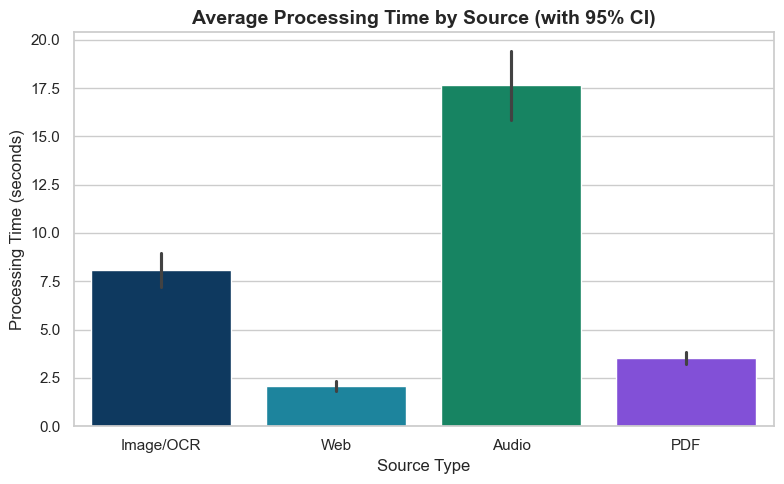

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

# seaborn automatically computes mean and 95% CI
sns.barplot(data=df, x='source_type', y='processing_time_sec',
            palette=['#003a6d', '#0891B2', '#059669', '#7C3AED'], ax=ax)

ax.set_title('Average Processing Time by Source (with 95% CI)', fontsize=14, fontweight='bold')
ax.set_xlabel('Source Type')
ax.set_ylabel('Processing Time (seconds)')

plt.tight_layout()
plt.show()

Notice the **black error bars** — those are 95% confidence intervals, computed automatically by seaborn. With raw matplotlib, you'd have to calculate and draw them yourself.

### 4.2 Distribution Plots

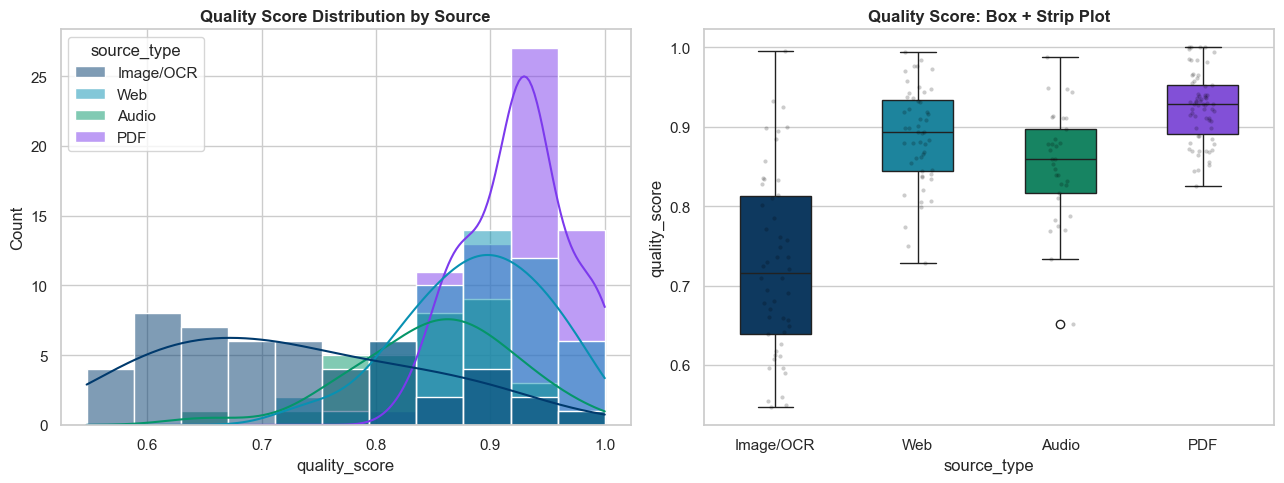

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram with KDE overlay
sns.histplot(data=df, x='quality_score', hue='source_type', 
             kde=True, alpha=0.5, ax=axes[0],
             palette=['#003a6d', '#0891B2', '#059669', '#7C3AED'])
axes[0].set_title('Quality Score Distribution by Source', fontweight='bold')

# Box + strip plot (shows individual points on top of boxes)
sns.boxplot(data=df, x='source_type', y='quality_score', 
            palette=['#003a6d', '#0891B2', '#059669', '#7C3AED'],
            ax=axes[1], width=0.5)
sns.stripplot(data=df, x='source_type', y='quality_score',
              color='black', alpha=0.2, size=3, ax=axes[1])
axes[1].set_title('Quality Score: Box + Strip Plot', fontweight='bold')

plt.tight_layout()
plt.show()

### 4.3 Heatmap — Correlation Matrix

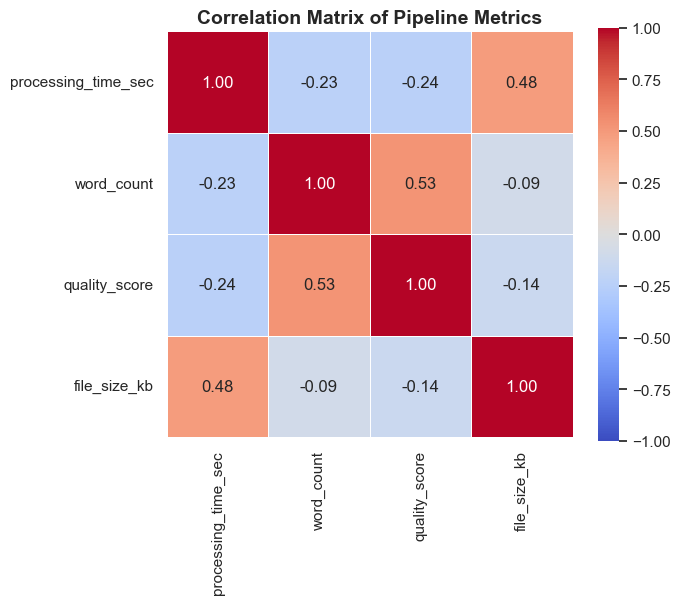

In [16]:
# Select numeric columns and compute correlations
numeric_cols = ['processing_time_sec', 'word_count', 'quality_score', 'file_size_kb']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix of Pipeline Metrics', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.4 Faceted Plots — Splitting by Category

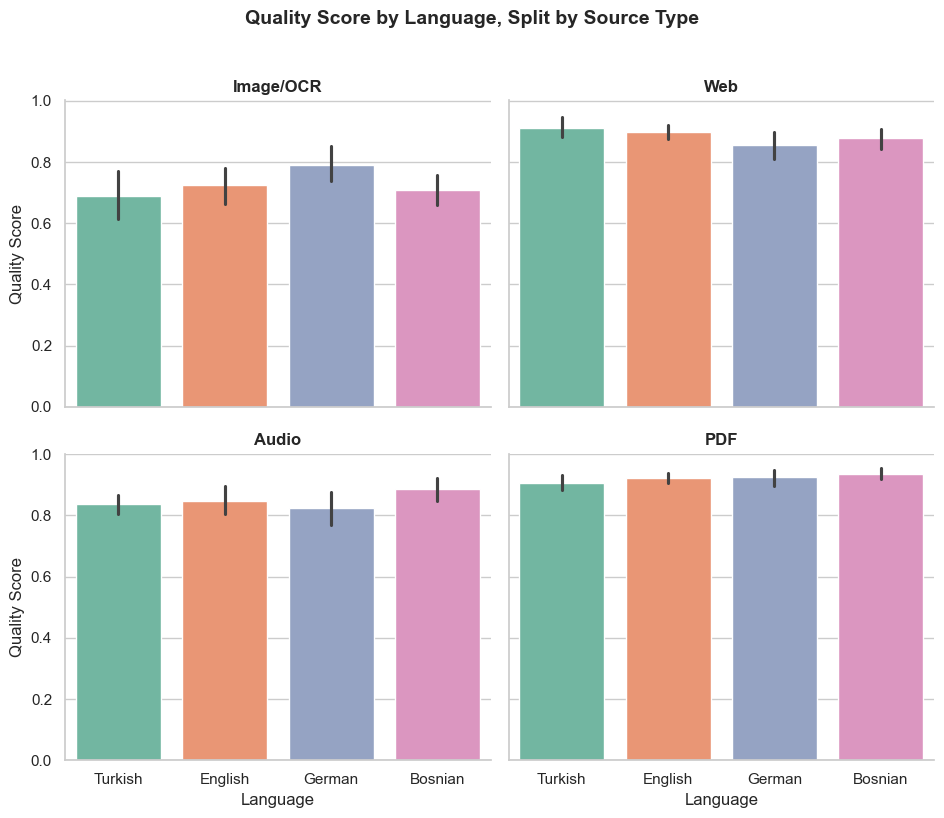

In [17]:
# catplot: bar plot split by source type and language
g = sns.catplot(data=df, x='language', y='quality_score',
                col='source_type', kind='bar', col_wrap=2,
                height=4, aspect=1.2, palette='Set2')
g.set_titles("{col_name}", fontweight='bold')
g.set_axis_labels("Language", "Quality Score")
g.fig.suptitle('Quality Score by Language, Split by Source Type', 
               fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

### 4.5 Pair Plot — Exploring All Relationships

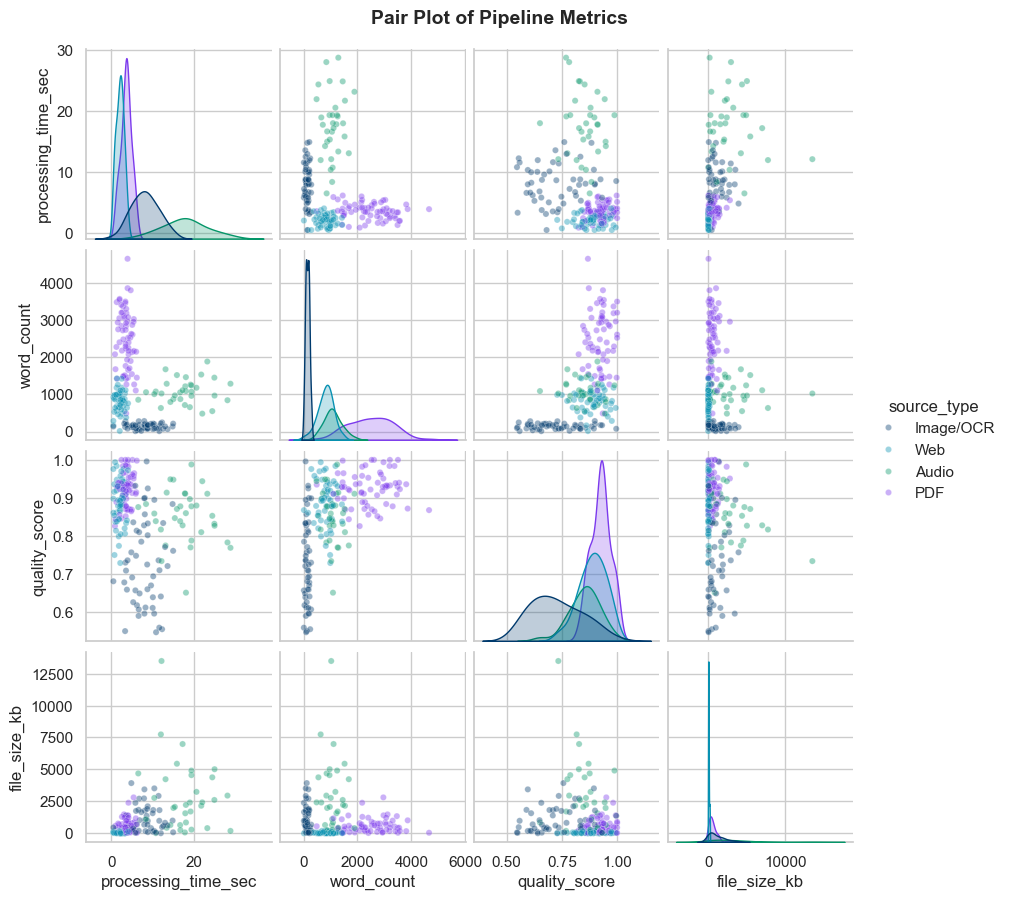

In [18]:
# Pair plot: scatter matrix of numeric columns, colored by source type
g = sns.pairplot(df[numeric_cols + ['source_type']], 
                 hue='source_type', diag_kind='kde',
                 palette=['#003a6d', '#0891B2', '#059669', '#7C3AED'],
                 plot_kws={'alpha': 0.4, 's': 20}, height=2.2)
g.fig.suptitle('Pair Plot of Pipeline Metrics', fontsize=14, fontweight='bold', y=1.02)

plt.show()

---
## 5. Plotly Express — Interactive Visualization

Plotly creates **interactive** charts: hover, zoom, pan, and selection are built in. Charts render directly in Jupyter and can be exported as standalone HTML files.

> **Note:** If Plotly is not installed, run: `pip install plotly`

In [19]:
import plotly.express as px
print("✓ Plotly Express loaded — charts below are interactive!")
print("  Hover over data points to see values. Click-drag to zoom.")

✓ Plotly Express loaded — charts below are interactive!
  Hover over data points to see values. Click-drag to zoom.


In [20]:
%pip install --upgrade nbformat



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### 5.1 Interactive Scatter Plot

In [21]:
fig = px.scatter(df, x='file_size_kb', y='processing_time_sec',
                 color='source_type', size='word_count',
                 hover_data=['language', 'quality_score'],
                 title='File Size vs Processing Time (hover for details)',
                 labels={'file_size_kb': 'File Size (KB)',
                         'processing_time_sec': 'Processing Time (sec)',
                         'source_type': 'Source'},
                 color_discrete_sequence=['#003a6d', '#0891B2', '#059669', '#7C3AED'])

fig.update_layout(template='plotly_white')
fig.show()

### 5.2 Interactive Bar Chart

In [22]:
# Average quality score by source and language
avg_quality = df.groupby(['source_type', 'language'])['quality_score'].mean().reset_index()

fig = px.bar(avg_quality, x='source_type', y='quality_score', color='language',
             barmode='group',
             title='Average Quality Score by Source and Language',
             labels={'quality_score': 'Quality Score', 'source_type': 'Source Type'},
             color_discrete_sequence=px.colors.qualitative.Set2)

fig.update_layout(template='plotly_white')
fig.show()

### 5.3 Interactive Histogram with Marginal Box Plot

In [23]:
fig = px.histogram(df, x='processing_time_sec', color='source_type',
                   marginal='box',
                   nbins=40,
                   title='Processing Time Distribution with Marginal Box Plot',
                   labels={'processing_time_sec': 'Processing Time (sec)'},
                   color_discrete_sequence=['#003a6d', '#0891B2', '#059669', '#7C3AED'])

fig.update_layout(template='plotly_white')
fig.show()

### 5.4 Heatmap with Plotly

In [24]:
fig = px.imshow(corr_matrix, text_auto='.2f',
                color_continuous_scale='RdBu_r',
                title='Correlation Matrix (Interactive)',
                labels=dict(color='Correlation'))

fig.update_layout(width=550, height=500)
fig.show()

### 5.5 Exporting Plotly Figures

In [25]:
# Export as interactive HTML
fig = px.scatter(df, x='word_count', y='quality_score',
                 color='source_type', 
                 title='Word Count vs Quality — Interactive Report',
                 color_discrete_sequence=['#003a6d', '#0891B2', '#059669', '#7C3AED'])
fig.update_layout(template='plotly_white')

fig.write_html('interactive_report.html')
print("✓ Saved: interactive_report.html")
print("  → Open this file in any browser to explore interactively")

# For static images (requires: pip install kaleido):
# fig.write_image('report_chart.png', scale=2)

✓ Saved: interactive_report.html
  → Open this file in any browser to explore interactively


---
## 6. Automated Report Generation

In practice, you often need to generate the **same charts repeatedly** — daily reports, per-region dashboards, per-client summaries. The pattern: **loop over data subsets → generate chart → save → close**.

### 6.1 Batch Chart Creation

In [34]:
import os
os.makedirs('reports', exist_ok=True)

# Generate one report per source type
for source in df['source_type'].unique():
    subset = df[df['source_type'] == source]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{source} — Pipeline Report', fontsize=14, fontweight='bold')
    
    # Chart 1: Quality distribution
    axes[0].hist(subset['quality_score'], bins=20, color='#003a6d', edgecolor='white')
    axes[0].set_title('Quality Distribution')
    axes[0].set_xlabel('Quality Score')
    axes[0].axvline(subset['quality_score'].mean(), color='#DC2626', linestyle='--',
                    label=f"Mean: {subset['quality_score'].mean():.3f}")
    axes[0].legend(fontsize=8)
    
    # Chart 2: Processing time by month
    monthly = subset.groupby('month')['processing_time_sec'].mean()
    axes[1].bar(monthly.index, monthly.values, color='#0891B2')
    axes[1].set_title('Avg Processing Time by Month')
    axes[1].set_ylabel('Seconds')
    
    # Chart 3: Language breakdown
    lang_counts = subset['language'].value_counts()
    axes[2].pie(lang_counts.values, labels=lang_counts.index, autopct='%1.0f%%',
                colors=['#003a6d', '#0891B2', '#059669', '#7C3AED'])
    axes[2].set_title('Language Breakdown')
    
    plt.tight_layout()
    filename = f'reports/{source.replace("/", "_")}_report.png'
    fig.savefig(filename, dpi=200, bbox_inches='tight')
    plt.close(fig)  # Important: free memory!
    print(f"✓ Saved: {filename}")

print(f"\n✓ Generated {len(df['source_type'].unique())} report files")

✓ Saved: reports/Image_OCR_report.png
✓ Saved: reports/Web_report.png
✓ Saved: reports/Audio_report.png
✓ Saved: reports/PDF_report.png

✓ Generated 4 report files


**Key points:**
- `plt.close(fig)` after each save — without this, matplotlib keeps all figures in memory
- `os.makedirs('reports', exist_ok=True)` — create output directory if it doesn't exist
- f-string filenames create unique files automatically

### 6.2 Reusable Dashboard Function

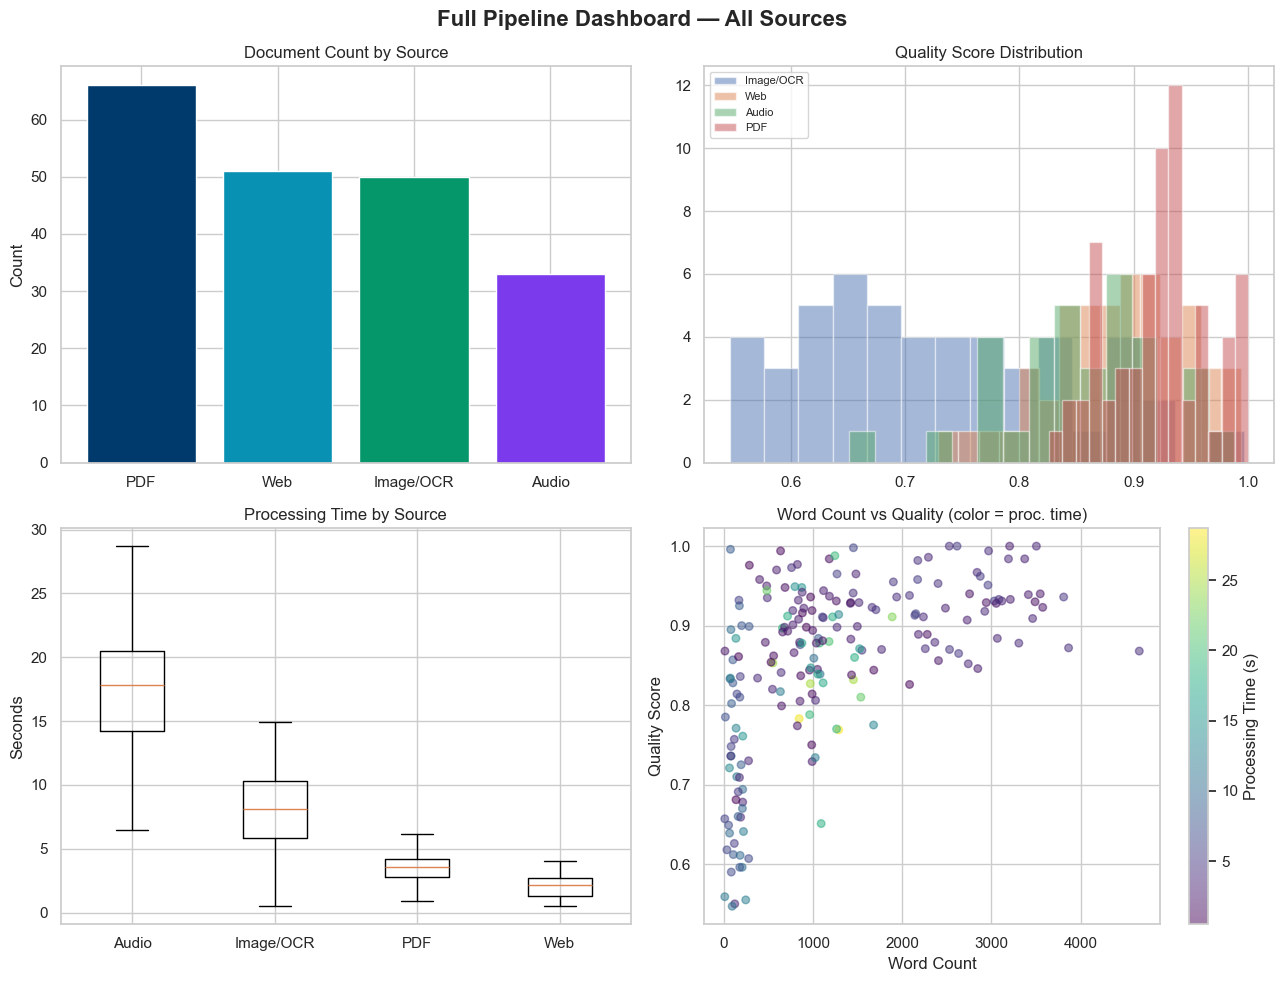

In [35]:
def create_dashboard(dataframe, title="Pipeline Dashboard", save_path=None):
    """Generate a 4-panel dashboard from pipeline data."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    # Panel 1: Bar chart
    counts = dataframe['source_type'].value_counts()
    axes[0, 0].bar(counts.index, counts.values,
                   color=['#003a6d', '#0891B2', '#059669', '#7C3AED'][:len(counts)])
    axes[0, 0].set_title('Document Count by Source')
    axes[0, 0].set_ylabel('Count')
    
    # Panel 2: Quality distribution
    for source in dataframe['source_type'].unique():
        subset = dataframe[dataframe['source_type'] == source]
        axes[0, 1].hist(subset['quality_score'], bins=15, alpha=0.5, label=source)
    axes[0, 1].set_title('Quality Score Distribution')
    axes[0, 1].legend(fontsize=8)
    
    # Panel 3: Processing time boxes
    source_types = sorted(dataframe['source_type'].unique())
    data_groups = [dataframe[dataframe['source_type'] == s]['processing_time_sec'] for s in source_types]
    axes[1, 0].boxplot(data_groups, labels=source_types)
    axes[1, 0].set_title('Processing Time by Source')
    axes[1, 0].set_ylabel('Seconds')
    
    # Panel 4: Scatter with color
    sc = axes[1, 1].scatter(dataframe['word_count'], dataframe['quality_score'],
                            c=dataframe['processing_time_sec'], cmap='viridis', alpha=0.5, s=30)
    axes[1, 1].set_title('Word Count vs Quality (color = proc. time)')
    axes[1, 1].set_xlabel('Word Count')
    axes[1, 1].set_ylabel('Quality Score')
    plt.colorbar(sc, ax=axes[1, 1], label='Processing Time (s)')
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Dashboard saved to: {save_path}")
    
    return fig

# Use the function
fig = create_dashboard(df, title="Full Pipeline Dashboard — All Sources")
plt.show()

In [36]:
# Generate one dashboard per language
for lang in df['language'].unique():
    subset = df[df['language'] == lang]
    fig = create_dashboard(subset, 
                           title=f"Pipeline Dashboard — {lang}",
                           save_path=f"reports/dashboard_{lang.lower()}.png")
    plt.close(fig)

print(f"\n✓ All language dashboards saved to reports/")

✓ Dashboard saved to: reports/dashboard_turkish.png
✓ Dashboard saved to: reports/dashboard_english.png
✓ Dashboard saved to: reports/dashboard_german.png
✓ Dashboard saved to: reports/dashboard_bosnian.png

✓ All language dashboards saved to reports/


---
## 7. Practice Exercises

Complete the following exercises using the `df` DataFrame we created above.

### Exercise 1: matplotlib Basics

Create a **horizontal bar chart** showing the average `word_count` by `language`. Sort the bars from highest to lowest. Add a title and axis labels.

In [29]:
# YOUR CODE HERE
# Hint: df.groupby('language')['word_count'].mean().sort_values()
# Hint: ax.barh(...)

### Exercise 2: Customization

Create a **scatter plot** of `word_count` vs `quality_score`. Color the points by `source_type`. Add:
- A descriptive title
- Axis labels
- A legend
- A horizontal dashed line at `quality_score = 0.8` with a label "Quality Threshold"

In [30]:
# YOUR CODE HERE

### Exercise 3: seaborn

Use `sns.catplot()` to create a **violin plot** (`kind='violin'`) showing the distribution of `processing_time_sec` for each `source_type`, with panels (columns) for each `language`.

*Hint: use `col='language'` and `col_wrap=2`.*

In [31]:
# YOUR CODE HERE

### Exercise 4: Plotly Express

Create an interactive scatter plot with:
- x = `processing_time_sec`, y = `quality_score`
- color = `source_type`
- Add `word_count` and `language` to hover data
- Use `template='plotly_white'`

Export it as `exercise4.html`.

In [32]:
# YOUR CODE HERE

### Exercise 5: Automated Reports

Write a loop that generates a **separate PNG** for each `language` in the dataset. Each chart should be a bar plot showing the count of documents by `source_type` for that language. Save to `reports/lang_<language>.png`.

In [33]:
# YOUR CODE HERE

---
## 8. Summary

| Library | Strength | Output | When to Use |
|---------|----------|--------|-------------|
| **matplotlib** | Full control, customizable | Static (PNG, PDF, SVG) | Publication-quality, full customization |
| **seaborn** | Statistical plots, beautiful defaults | Static (via matplotlib) | Distributions, categories, correlations |
| **Plotly Express** | Interactive, web-ready | Interactive (HTML, Jupyter) | Dashboards, exploration, sharing |

**Key takeaways:**
1. Choose chart type by **purpose**: comparison → bar, trend → line, relationship → scatter, distribution → histogram/box
2. Use the **object-oriented** matplotlib API: `fig, ax = plt.subplots()`
3. seaborn handles **aggregation and confidence intervals** automatically
4. Plotly charts are **interactive by default** — hover, zoom, pan, select
5. For automated reports: **loop → plot → save → `plt.close(fig)`**

*IT 2012 — Unstructured Data. International Burch University. Week 12 lab.*